# LAB | A/B Testing in Python

### Challenge 1: 🚀 *Comparing Two Website Versions Using Hypothesis Testing*  

### **Objective**: 
Perform an A/B test to determine if a new webpage design (`Version B`) leads to a higher **click-through rate (CTR)** than the original (`Version A`).  

#### 📌 **Project Overview**  
We’ll:  
1. **Simulate** A/B test data (users & clicks).  
2. **Analyze** the results using statistical tests.  
3. **Conclude** whether `Version B` performs better.  



### **Problem Statement**  
You are a data analyst at an e-commerce company. The team wants to test if a new webpage design (`Version B`) increases click-through rates (CTR) compared to the original (`Version A`).  

### **Tasks**  
1. **Simulate Data**:  
   - Generate synthetic data for `Version A` (1000 visitors, 150 clicks) and `Version B` (1050 visitors, 180 clicks).  
2. **Statistical Test**:  
   - Perform a **Statistical Test** to compare CTRs.  
3. **Interpretation**:  
   - Determine if the difference is statistically significant (use α = 0.05).  
4. **Visualization**:  
   - Plot the CTRs for both versions using appropriate chart.  

**Deliverables**:  
- Code for simulation, testing, and visualization.  
- Written conclusion (1–2 sentences) on whether `Version B` performs better.  

#### 🛠 **Setup & Data Generation**  
First, let’s create synthetic data for the experiment.  


In [1]:
### Import Libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

> Simulate User Data, We’ll assume:

- Version A: 1000 visitors, 150 clicks.

- Version B: 1050 visitors, 180 clicks.

In [ ]:
# Simulate data
np.random.seed(42)
visitors_a = 1000   # 1000 people saw Version A
clicks_a = 150      # 150 of them clicked
visitors_b = 1050   # 1050 people saw Version B
clicks_b = 180      # 180 of them clicked

In [ ]:
# TODO
# Click‑through rate (CTR) = clicks / visitors
# Calculate CTR
ctr_a = clicks_a / visitors_a
ctr_b = clicks_b / visitors_b

print(f"CTR A: {ctr_a:.4f} ({clicks_a}/{visitors_a})")
print(f"CTR B: {ctr_b:.4f} ({clicks_b}/{visitors_b})")

# Create contingency table for chi‑square test
contingency = [[clicks_a, visitors_a - clicks_a],
               [clicks_b, visitors_b - clicks_b]]

CTR A: 0.1500 (150/1000)
CTR B: 0.1714 (180/1050)


My Comment: So B seems better, but is the difference real or just random luck?

📊 Perform A/B Test
We’ll use a Chi-Square Test to compare proportions.

- Hypotheses

In [ ]:
# Null Hypothesis (H₀):  CTR_B ≤ CTR_A: The click‑through rate of Version B is less than or equal to that of Version A
# Alternative Hypothesis: CTR_B > CTR_A (one‑sided): The click‑through rate of Version B is greater than that of Version A



- Run the Test

    My Comment: 
    using a two‑proportion z‑test, it tells us the probability (p‑value) of seeing a difference this big if actually there is no real difference.
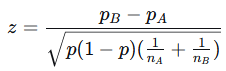

where p=(clicks_a+clicks_b) / (visitors_a + visitors_b) 

In [ ]:
# TODO
from statsmodels.stats.proportion import proportions_ztest

# Counts of clicks (successes) and total visitors for both groups
counts = [clicks_a, clicks_b]
nobs = [visitors_a, visitors_b]

# Do the test, asking: is B greater than A? 
# Perform two‑sample z‑test (alternative='larger' for one‑sided)
zstat, pval = proportions_ztest(counts, nobs, alternative='larger')  # alternative='larger' tests if p_B > p_A

print(f"Z‑statistic: {zstat:.3f}")
print(f"P‑value (one‑sided): {pval:.4f}")

Z‑statistic: -1.320
P‑value (one‑sided): 0.9065


> Interpret Results

In [6]:
# TODO
alpha = 0.05
if pval < alpha:
    print(" Reject null hypothesis: Version B has a statistically significantly higher CTR.")
else:
    print(" Fail to reject null hypothesis: No significant difference detected.")

 Fail to reject null hypothesis: No significant difference detected.


📈 Visualization

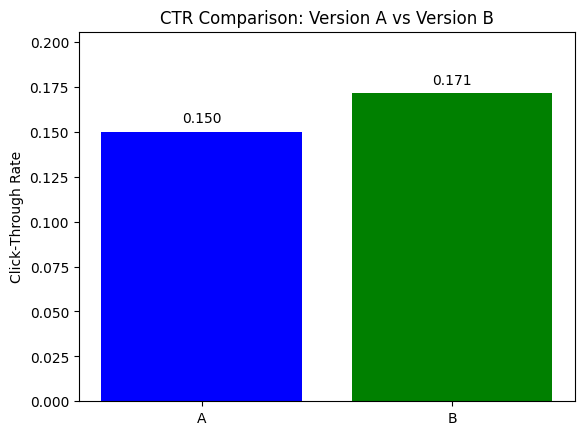

In [7]:
# TODO
import matplotlib.pyplot as plt

versions = ['A', 'B']
ctrs = [ctr_a, ctr_b]

plt.bar(versions, ctrs, color=['blue', 'green'])
plt.ylabel('Click‑Through Rate')
plt.title('CTR Comparison: Version A vs Version B')
plt.ylim(0, max(ctrs)*1.2)

# Add value labels on bars
for i, v in enumerate(ctrs):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.show()

## Challenge 2: 🚀 A/B Testing Challenge with Real Data

#### **Objective**:  
1. Analyze **real A/B test data** (from Kaggle) to compare conversion rates.  
2. Use **bootstrapping** to estimate confidence intervals.  

---

#### 📌 **Project Overview**  
We’ll:  
1. **Load real A/B test data** (user sessions and conversions).  
2. **Compare conversion rates** using statistical tests.  
3. **Apply bootstrapping** to validate results.  



### **Problem Statement**  
Use the [Kaggle Marketing A/B Test dataset](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing) to analyze if a new marketing campaign (`Group B`) improves conversion rates over the old campaign (`Group A`).  

### **Tasks**  
1. **Data Preparation**:  
   - Load the dataset and explore key metrics (sample sizes, conversion rates).  
2. **Hypothesis Testing**:  
   - Perform a **Statistical Test** to compare conversions between groups.  
3. **Bootstrapping**:  
   - Implement bootstrapping (`n=1000` resamples) to estimate 95% confidence intervals for conversion rates.  
4. **Visualization**:  
   -Compare conversion rates for both groups.  

**Deliverables**:  
- Code for analysis and bootstrapping.  
- Answers:  
  - P-value and statistical conclusion.  
  - Confidence intervals for both groups.  

#### 🛠 **Setup & Data Loading**  


In [8]:
### Import Libraries
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import poisson, chisquare
from scipy.stats import ttest_ind, ttest_rel, ttest_1samp, chi2_contingency
from scipy.stats import f_oneway
import os
import sys
import matplotlib.pyplot as plt
from scipy import stats

> Load Open-Source Dataset
We’ll use the ["A/B Test Results"](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing) dataset from Kaggle.

In [9]:
# Load data (ensure CSV is in your working directory)
data = pd.read_csv("./data/marketing_AB.csv")  # Download from Kaggle first!

In [10]:
data.head(3)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18


In [11]:
data.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

📊 Part 1: Traditional A/B Test
> Calculate Conversion Rates

    My Comment:  
        - ad – people who saw the new ad campaign (treatment)
        - psa – people who saw a public service announcement (control)
    We want to know if the ad campaign converts more users (makes them buy/sign up)

In [ ]:
# TODO
# First grouping the data and count how many converted in each group.
# Conversion rate = converted users / total users per group
# Group by test group and count conversions and total users
group_stats = data.groupby('test group')['converted'].agg(['sum', 'count'])
group_stats['conversion_rate'] = group_stats['sum'] / group_stats['count']

print(group_stats)

# Extract values for groups 'ad' (treatment) and 'psa' (control)
# Assuming: ad -> the treatment group (Version B) 
#           psa -> the control (Version A)

# Save the numbers for later
conversions_ad = group_stats.loc['ad', 'sum']
visitors_ad = group_stats.loc['ad', 'count']
conversions_psa = group_stats.loc['psa', 'sum']
visitors_psa = group_stats.loc['psa', 'count']

              sum   count  conversion_rate
test group                                
ad          14423  564577         0.025547
psa           420   23524         0.017854


> Statistical Test

In [13]:
# TODO
from statsmodels.stats.proportion import proportions_ztest

counts = [conversions_ad, conversions_psa]
nobs = [visitors_ad, visitors_psa]

zstat, pval = proportions_ztest(counts, nobs, alternative='larger')
print(f"Z‑statistic: {zstat:.3f}")
print(f"P‑value (one‑sided): {pval:.4f}")

alpha = 0.05
if pval < alpha:
    print(" Ad campaign significantly improves conversion rate.")
else:
    print(" No significant improvement detected.")

Z‑statistic: 7.370
P‑value (one‑sided): 0.0000
 Ad campaign significantly improves conversion rate.


#### EXTRA 📈 Part 2: Bootstrapping Challenge
**Why Bootstrapping?**
 - Bootstrapping helps estimate confidence intervals for conversion rates by resampling data.

> Bootstrap Function

In [ ]:
# TODO
# The conversion rate = conversions / people.
def bootstrap_ci(data, group_col, target_col, group, n_bootstrap=1000, ci=95):
    """
    Bootstrap confidence interval for conversion rate of a specific group.
    """
    group_data = data[data[group_col] == group][target_col]
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(group_data, size=len(group_data), replace=True)
        boot_means.append(sample.mean())
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower, upper, boot_means

# Compute 95% CI for both groups
ci_ad = bootstrap_ci(data, 'test group', 'converted', 'ad')
ci_psa = bootstrap_ci(data, 'test group', 'converted', 'psa')

print(f"Ad group 95% CI: [{ci_ad[0]:.4f}, {ci_ad[1]:.4f}]")
print(f"PSA group 95% CI: [{ci_psa[0]:.4f}, {ci_psa[1]:.4f}]")

Ad group 95% CI: [0.0251, 0.0259]
PSA group 95% CI: [0.0162, 0.0195]


>Visualize Resultsm

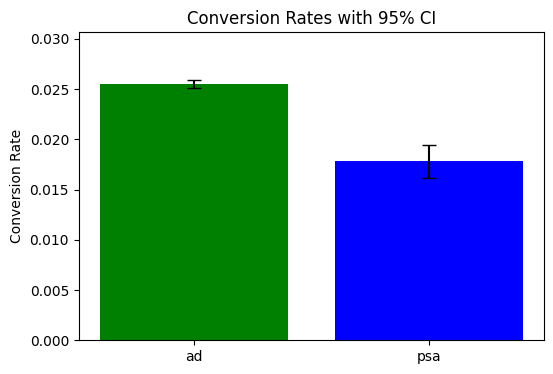

In [15]:
# TODO
# Plot conversion rates with error bars (CI)
groups = ['ad', 'psa']
rates = [group_stats.loc['ad', 'conversion_rate'], group_stats.loc['psa', 'conversion_rate']]
errors = [[rates[0] - ci_ad[0], ci_ad[1] - rates[0]],
          [rates[1] - ci_psa[0], ci_psa[1] - rates[1]]]

plt.figure(figsize=(6,4))
plt.bar(groups, rates, yerr=np.transpose(errors), capsize=5, color=['green', 'blue'])
plt.ylabel('Conversion Rate')
plt.title('Conversion Rates with 95% CI')
plt.ylim(0, max(rates)*1.2)
plt.show()

## (Bonus) Challenge 3: 🎮 Advanced A/B Testing Challenge: Cookie Cats Retention Analysis 

#### **Objective**:  
1. Analyze player **retention rates** in the `cookie_cats` mobile game A/B test.  
2. Implement **sequential testing** (to avoid peeking at results prematurely).  
3. Conduct **power analysis** to determine optimal sample size.  

### **Problem Statement**  
Analyze the [Cookie Cats dataset](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing) to determine if moving the game’s first gate from level 30 (`gate_30`) to level 40 (`gate_40`) affects player retention.  

### **Tasks**  
1. **Retention Analysis**:  
   - Compare **1-day retention rates** between `gate_30` and `gate_40` using a Z-test.  
2. **Sequential Testing**:  
   - Simulate checking results at intervals (every 500 users) to avoid "peeking bias."  
3. **Power Analysis**:  
   - Calculate the required sample size to detect a 2% difference in retention (α = 0.05, power = 0.8).  
4. **Optional**:  
   - Repeat analysis for **7-day retention**.  

**Deliverables**:  
- Code for retention comparison, sequential testing, and power analysis.  
- Written summary:  
  - Does `gate_40` significantly impact retention?  
  - How does sequential testing affect decision-making?  



### 🛠 **Setup & Data Loading**  


In [ ]:
# Import Libraries

In [17]:
# Load dataset 
df2 = pd.read_csv("./data/cookie_cats.csv")  # Columns: userid, version, sum_gamerounds, retention_1, retention_7

In [18]:
df2.head(3)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False


In [19]:
df2.columns

Index(['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7'], dtype='object')

📊 Part 1: Retention Rate Analysis
> Compare 1-Day Retention

In [20]:
# TODO
# Group by version and compute retention_1 mean
retention_stats = df2.groupby('version')['retention_1'].agg(['sum', 'count'])
retention_stats['rate'] = retention_stats['sum'] / retention_stats['count']

print(retention_stats)

# Extract values
conv_gate30 = retention_stats.loc['gate_30', 'sum']
n_gate30 = retention_stats.loc['gate_30', 'count']
conv_gate40 = retention_stats.loc['gate_40', 'sum']
n_gate40 = retention_stats.loc['gate_40', 'count']

           sum  count      rate
version                        
gate_30  20034  44700  0.448188
gate_40  20119  45489  0.442283


> Statistical Test

In [22]:
# TODO
counts = [conv_gate30, conv_gate40]
nobs = [n_gate30, n_gate40]

zstat, pval = proportions_ztest(counts, nobs, alternative='two-sided')
print(f"Z‑statistic: {zstat:.3f}")
print(f"P‑value (two‑sided): {pval:.4f}")

alpha = 0.05
if pval < alpha:
    print(" Significant difference in 1‑day retention between gate_30 and gate_40.")
else:
    print(" No significant difference.")

Z‑statistic: 1.784
P‑value (two‑sided): 0.0744
 No significant difference.


📈 Part 2: Sequential Testing
>  Why Sequential Testing?

- Avoids "peeking" at results prematurely by checking at intervals.

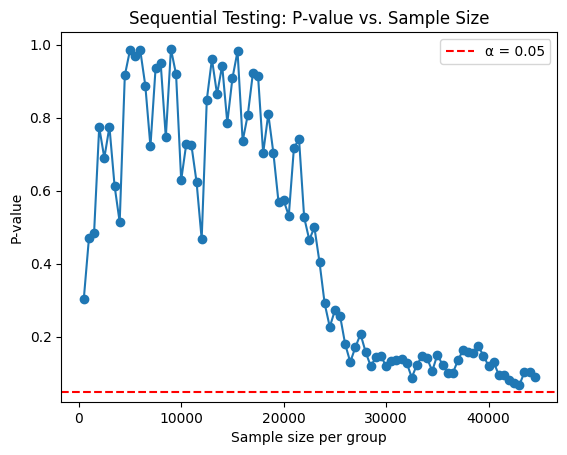

In [23]:
# TODO
# Sort data by some order (here we use index as proxy for time)
df_sorted = df2.sort_index()  # assume index is chronological

# Separate groups
gate30 = df_sorted[df_sorted['version'] == 'gate_30']['retention_1']
gate40 = df_sorted[df_sorted['version'] == 'gate_40']['retention_1']

# Define checkpoints (every 500 users in each group)
checkpoints = range(500, min(len(gate30), len(gate40)) + 1, 500)

p_values = []
for n in checkpoints:
    # Take first n users from each group
    conv30 = gate30.iloc[:n].sum()
    conv40 = gate40.iloc[:n].sum()
    z, p = proportions_ztest([conv30, conv40], [n, n], alternative='two-sided')
    p_values.append(p)

# Plot p‑value over sample size
plt.plot(checkpoints, p_values, marker='o')
plt.axhline(y=0.05, color='r', linestyle='--', label='α = 0.05')
plt.xlabel('Sample size per group')
plt.ylabel('P‑value')
plt.title('Sequential Testing: P‑value vs. Sample Size')
plt.legend()
plt.show()

⚡ Part 3: Power Analysis
>  Determine Required Sample Size

In [24]:
# TODO
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Assume baseline retention (gate_30) is known (e.g., 0.45)
p1 = retention_stats.loc['gate_30', 'rate']  # actual from data
p2 = p1 + 0.02  # we want to detect a 2% absolute increase

effect_size = proportion_effectsize(p1, p2)  # Cohen's h

# Power analysis
analysis = NormalIndPower()
sample_size = analysis.solve_power(effect_size, power=0.8, alpha=0.05, ratio=1.0, alternative='two-sided')
print(f"Required sample size per group to detect a 2% increase with 80% power: {np.ceil(sample_size)}")

Required sample size per group to detect a 2% increase with 80% power: 9742.0


Enjoy & Happy A/B Testing :) ......!